# ⚡ Big Data Libraries: A Head-to-Head Comparison
## pandas vs. Polars vs. Dask vs. Spark – Practical Session 5

When datasets grow, the choice of library matters. In this session we run the **same analysis tasks** on the **same data** using four different Python libraries — and measure what happens as the data scales up.

| Part | Topic | Goal |
|---|---|---|
| 1 | **Meet the Contenders** | Install all four libraries and understand their design philosophy |
| 2 | **The Dataset** | Load 114k Spotify tracks and create scaled-up versions |
| 3 | **Benchmark: Core Operations** | Filter, group, aggregate, sort – timed across all four libraries |
| 4 | **Benchmark: Analytics Pipeline** | A realistic multi-step analysis, timed end-to-end |
| 5 | **Visualise & Interpret** | Compare results and discuss when to use which library |
| 6 | **Group Activity** | Each group explores a different angle |

> 💡 **Note:** This notebook runs entirely in Google Colab – no local installation needed.

**Dataset:** [Spotify Tracks](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset) — 114,000 tracks across 114 genres with audio features like energy, danceability, tempo, and more.

## 📦 Step 0: Install & Import Libraries

In [1]:
!pip install datasets polars dask[dataframe] pyspark --quiet


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/29 00:23:16 WARN Utils: Your hostname, TEQ0013, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/04/29 00:23:16 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/29 00:23:17 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


AttributeError: module 'dask.dataframe' has no attribute '__version__'

In [4]:

import pandas as pd
import polars as pl
import dask.dataframe as dd
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import dask

import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

# Start Spark (we'll need it throughout)
spark = SparkSession.builder \
    .appName('Library Comparison') \
    .master('local[*]') \
    .config('spark.sql.shuffle.partitions', '4') \
    .config('spark.driver.memory', '4g') \
    .getOrCreate()

print(f'pandas {pd.__version__}  |  polars {pl.__version__}  |  dask {dask.__version__}  |  spark {spark.version}')
print('✅ All libraries loaded!')

pandas 3.0.2  |  polars 1.40.1  |  dask 2026.3.0  |  spark 4.1.1
✅ All libraries loaded!


---
## 📦 Part 1: Meet the Contenders

All four libraries work with tabular data — but they have very different design philosophies:

| Library | Design philosophy | Execution | Best for |
|---|---|---|---|
| **pandas** | Single-machine, eager, row-oriented | Immediate | Exploration, small–medium data (<1 GB) |
| **Polars** | Single-machine, lazy-capable, columnar (Arrow) | Eager or lazy | Fast analytics, medium data (1–50 GB) |
| **Dask** | Parallel pandas — splits DataFrames into partitions | Lazy | Scaling pandas workflows across cores |
| **Spark** | Distributed cluster engine (JVM-based) | Lazy | True Big Data on clusters (TB+) |

### Key differences at a glance

| Feature | pandas | Polars | Dask | Spark |
|---|---|---|---|---|
| Written in | Python / C | Rust | Python | Scala / Java |
| Memory model | Row-oriented | Columnar (Apache Arrow) | Partitioned pandas | Distributed (JVM) |
| Lazy evaluation | ❌ | ✅ (optional) | ✅ | ✅ |
| Multi-core | ❌ (single thread) | ✅ (automatic) | ✅ | ✅ |
| Cluster support | ❌ | ❌ | ✅ (limited) | ✅ (full) |
| SQL interface | ❌ | ✅ | ❌ | ✅ |
| Startup overhead | Minimal | Minimal | Moderate | High |

> 💡 **Why does this matter?** pandas is the tool most data scientists learn first. But as data grows, you need to know *when* to switch — and to *what*.

---
## 📦 Part 2: Load the Dataset & Create Scale Levels

We use the **Spotify Tracks Dataset** — 114,000 real tracks with rich audio features. To test scaling behaviour, we create larger versions by tiling the data.

> 🎯 **Task:** Load the data and create 4 scale levels: 10k, 100k, 500k, and 2M rows.

In [5]:
# Load the real Spotify dataset from HuggingFace
raw = load_dataset('maharshipandya/spotify-tracks-dataset', split='train')
df_full = raw.to_pandas()

# Keep the most useful columns
KEEP_COLS = ['track_name', 'artists', 'album_name', 'track_genre',
             'popularity', 'duration_ms', 'danceability', 'energy',
             'loudness', 'speechiness', 'acousticness', 'instrumentalness',
             'liveness', 'valence', 'tempo']

df_full = df_full[KEEP_COLS].copy()
df_full['duration_min'] = (df_full['duration_ms'] / 60_000).round(2)

print(f'Original dataset: {len(df_full):,} rows × {len(df_full.columns)} columns')
print(f'Memory: {df_full.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
df_full.head(3)

Original dataset: 114,000 rows × 16 columns
Memory: 20.8 MB


,track_name,artists,album_name,track_genre,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_min
0,Comedy,Gen Hoshino,Comedy,acoustic,73,230666,0.676,0.461,-6.746,0.1430,0.0322,0.000001,0.358,0.715,87.917,3.84
1,Ghost - Acoustic,Ben Woodward,Ghost (Acoustic),acoustic,55,149610,0.420,0.166,-17.235,0.0763,0.9240,0.000006,0.101,0.267,77.489,2.49
2,To Begin Again,Ingrid Michaelson;ZAYN,To Begin Again,acoustic,57,210826,0.438,0.359,-9.734,0.0557,0.2100,0.000000,0.117,0.120,76.332,3.51


### Column Reference

| Column | Type | Description |
|---|---|---|
| `track_name` | string | Name of the track |
| `artists` | string | Artist name(s) |
| `album_name` | string | Album name |
| `track_genre` | string | Genre label (114 genres) |
| `popularity` | int | Spotify popularity score (0–100) |
| `duration_ms` | int | Track duration in milliseconds |
| `danceability` | float | How suitable for dancing (0.0–1.0) |
| `energy` | float | Intensity and activity (0.0–1.0) |
| `loudness` | float | Overall loudness in dB |
| `tempo` | float | Estimated tempo in BPM |
| `valence` | float | Musical positiveness (0.0 = sad, 1.0 = happy) |
| `duration_min` | float | Duration in minutes (computed) |

In [14]:
# Create scaled versions by sampling and tiling

SCALE_LEVELS = {
    '10k':   10_000,
    '500k':  500_000,
    '2M':    2_000_000,
    '10M':  10_000_000,
}

datasets_pd = {}
for label, target_rows in SCALE_LEVELS.items():
    if target_rows <= len(df_full):
        df_scaled = df_full.sample(n=target_rows, random_state=42).reset_index(drop=True)
    else:
        repeats = (target_rows // len(df_full)) + 1
        df_scaled = pd.concat([df_full] * repeats, ignore_index=True).head(target_rows)
        # Add slight noise to numeric columns to keep it realistic
        for col in ['popularity', 'danceability', 'energy', 'tempo', 'valence']:
            noise = np.random.normal(0, 0.01, len(df_scaled))
            df_scaled[col] = (df_scaled[col] + noise).clip(
                df_full[col].min(), df_full[col].max()
            )
    datasets_pd[label] = df_scaled
    mem_mb = df_scaled.memory_usage(deep=True).sum() / 1024**2
    print(f'{label:>4}: {len(df_scaled):>10,} rows  |  {mem_mb:6.1f} MB')

print('\n✅ All scale levels ready.')

 10k:     10,000 rows  |     1.8 MB
500k:    500,000 rows  |    91.1 MB
  2M:  2,000,000 rows  |   364.3 MB
 10M: 10,000,000 rows  |  1822.0 MB

✅ All scale levels ready.


---
## 📦 Part 3: Benchmark — Core Operations

We run four fundamental operations on each library at each scale level and measure the time:

| Operation | What it tests |
|---|---|
| **Filter** | Select rows where `energy > 0.8` |
| **GroupBy + Aggregate** | Average popularity per genre |
| **Sort** | Sort all rows by `tempo` descending |
| **Computed Column** | Add `energy_dance_ratio = energy / danceability` |

> 🎯 **Task:** Run the benchmarks and observe how each library scales.

In [7]:
def benchmark_pandas(df):
    """Run all four operations with pandas."""
    times = {}

    t = time.time()
    _ = df[df['energy'] > 0.8]
    times['filter'] = time.time() - t

    t = time.time()
    _ = df.groupby('track_genre')['popularity'].mean()
    times['groupby'] = time.time() - t

    t = time.time()
    _ = df.sort_values('tempo', ascending=False)
    times['sort'] = time.time() - t

    t = time.time()
    _ = df.assign(energy_dance_ratio=df['energy'] / df['danceability'].replace(0, np.nan))
    times['computed_col'] = time.time() - t

    return times


def benchmark_polars(df_pd):
    """Run all four operations with Polars (lazy mode)."""
    df = pl.from_pandas(df_pd).lazy()
    times = {}

    t = time.time()
    _ = df.filter(pl.col('energy') > 0.8).collect()
    times['filter'] = time.time() - t

    t = time.time()
    _ = df.group_by('track_genre').agg(pl.col('popularity').mean()).collect()
    times['groupby'] = time.time() - t

    t = time.time()
    _ = df.sort('tempo', descending=True).collect()
    times['sort'] = time.time() - t

    t = time.time()
    _ = df.with_columns(
        (pl.col('energy') / pl.when(pl.col('danceability') == 0).then(None)
         .otherwise(pl.col('danceability'))).alias('energy_dance_ratio')
    ).collect()
    times['computed_col'] = time.time() - t

    return times


def benchmark_dask(df_pd):
    """Run all four operations with Dask."""
    df = dd.from_pandas(df_pd, npartitions=4)
    times = {}

    t = time.time()
    _ = df[df['energy'] > 0.8].compute()
    times['filter'] = time.time() - t

    t = time.time()
    _ = df.groupby('track_genre')['popularity'].mean().compute()
    times['groupby'] = time.time() - t

    t = time.time()
    _ = df.sort_values('tempo', ascending=False).compute()
    times['sort'] = time.time() - t

    t = time.time()
    _ = df.assign(energy_dance_ratio=df['energy'] / df['danceability'].replace(0, np.nan)).compute()
    times['computed_col'] = time.time() - t

    return times


def benchmark_spark(df_pd, spark_session):
    """Run all four operations with Spark."""
    df = spark_session.createDataFrame(df_pd)
    df.cache()          # warm up: load into Spark memory
    df.count()          # force materialisation
    times = {}

    t = time.time()
    _ = df.filter(F.col('energy') > 0.8).count()
    times['filter'] = time.time() - t

    t = time.time()
    _ = df.groupBy('track_genre').agg(F.avg('popularity')).collect()
    times['groupby'] = time.time() - t

    t = time.time()
    _ = df.orderBy(F.col('tempo').desc()).collect()
    times['sort'] = time.time() - t

    t = time.time()
    _ = df.withColumn('energy_dance_ratio',
            F.when(F.col('danceability') == 0, None)
             .otherwise(F.col('energy') / F.col('danceability'))
          ).count()
    times['computed_col'] = time.time() - t

    df.unpersist()
    return times


print('✅ Benchmark functions defined.')

✅ Benchmark functions defined.


In [8]:
# Run all benchmarks — this takes a few minutes

LIBRARIES = ['pandas', 'polars', 'dask', 'spark']
benchmark_funcs = {
    'pandas': benchmark_pandas,
    'polars': benchmark_polars,
    'dask':   benchmark_dask,
    'spark':  lambda df_pd: benchmark_spark(df_pd, spark),
}

all_results = []

for scale_label, df_pd in datasets_pd.items():
    n_rows = len(df_pd)
    print(f'\n{"=" * 50}')
    print(f'Scale: {scale_label} ({n_rows:,} rows)')
    print(f'{"=" * 50}')

    for lib_name in LIBRARIES:
        print(f'  {lib_name:<8}', end=' → ', flush=True)
        try:
            times = benchmark_funcs[lib_name](df_pd)
            total = sum(times.values())
            print(f'total: {total:.3f}s  (filter: {times["filter"]:.3f}  '
                  f'groupby: {times["groupby"]:.3f}  sort: {times["sort"]:.3f}  '
                  f'col: {times["computed_col"]:.3f})')
            for op, t in times.items():
                all_results.append({
                    'library': lib_name, 'scale': scale_label,
                    'n_rows': n_rows, 'operation': op, 'time_s': t
                })
        except Exception as e:
            print(f'ERROR: {e}')

df_results = pd.DataFrame(all_results)
print(f'\n✅ Benchmarks complete: {len(df_results)} measurements.')


Scale: 10k (10,000 rows)
  pandas   → total: 0.034s  (filter: 0.007  groupby: 0.021  sort: 0.006  col: 0.001)
  polars   → total: 0.057s  (filter: 0.026  groupby: 0.022  sort: 0.008  col: 0.001)
  dask     → total: 0.224s  (filter: 0.070  groupby: 0.115  sort: 0.017  col: 0.022)
  spark    → 

total: 3.084s  (filter: 0.597  groupby: 1.064  sort: 1.171  col: 0.252)

Scale: 100k (100,000 rows)
  pandas   → total: 0.085s  (filter: 0.016  groupby: 0.008  sort: 0.058  col: 0.003)
  polars   → total: 0.059s  (filter: 0.011  groupby: 0.022  sort: 0.025  col: 0.001)
  dask     → total: 0.257s  (filter: 0.069  groupby: 0.089  sort: 0.064  col: 0.035)
  spark    → 

26/04/29 00:25:17 WARN TaskSetManager: Stage 17 contains a task of very large size (1236 KiB). The maximum recommended task size is 1000 KiB.
26/04/29 00:25:18 WARN TaskSetManager: Stage 18 contains a task of very large size (1236 KiB). The maximum recommended task size is 1000 KiB.
26/04/29 00:25:18 WARN TaskSetManager: Stage 21 contains a task of very large size (1236 KiB). The maximum recommended task size is 1000 KiB.
26/04/29 00:25:18 WARN TaskSetManager: Stage 24 contains a task of very large size (1236 KiB). The maximum recommended task size is 1000 KiB.
26/04/29 00:25:19 WARN TaskSetManager: Stage 27 contains a task of very large size (1236 KiB). The maximum recommended task size is 1000 KiB.
26/04/29 00:25:19 WARN TaskSetManager: Stage 28 contains a task of very large size (1236 KiB). The maximum recommended task size is 1000 KiB.


total: 2.386s  (filter: 0.462  groupby: 0.276  sort: 1.406  col: 0.241)

Scale: 500k (500,000 rows)
  pandas   → 

26/04/29 00:25:20 WARN TaskSetManager: Stage 31 contains a task of very large size (1236 KiB). The maximum recommended task size is 1000 KiB.


total: 0.306s  (filter: 0.055  groupby: 0.024  sort: 0.219  col: 0.008)
  polars   → total: 0.130s  (filter: 0.010  groupby: 0.019  sort: 0.099  col: 0.002)
  dask     → total: 0.618s  (filter: 0.085  groupby: 0.128  sort: 0.337  col: 0.068)
  spark    → 

26/04/29 00:25:40 WARN TaskSetManager: Stage 34 contains a task of very large size (6188 KiB). The maximum recommended task size is 1000 KiB.
26/04/29 00:25:42 WARN TaskSetManager: Stage 35 contains a task of very large size (6188 KiB). The maximum recommended task size is 1000 KiB.
26/04/29 00:25:42 WARN TaskSetManager: Stage 38 contains a task of very large size (6188 KiB). The maximum recommended task size is 1000 KiB.
26/04/29 00:25:42 WARN TaskSetManager: Stage 41 contains a task of very large size (6188 KiB). The maximum recommended task size is 1000 KiB.
26/04/29 00:25:43 WARN TaskSetManager: Stage 44 contains a task of very large size (6188 KiB). The maximum recommended task size is 1000 KiB.
26/04/29 00:25:43 WARN TaskSetManager: Stage 45 contains a task of very large size (6188 KiB). The maximum recommended task size is 1000 KiB.
26/04/29 00:25:48 WARN TaskSetManager: Stage 48 contains a task of very large size (6188 KiB). The maximum recommended task size is 1000 KiB.


total: 6.505s  (filter: 0.375  groupby: 0.524  sort: 5.215  col: 0.391)

Scale: 2M (2,000,000 rows)
  pandas   → total: 1.671s  (filter: 0.286  groupby: 0.084  sort: 1.273  col: 0.028)
  polars   → total: 0.436s  (filter: 0.021  groupby: 0.027  sort: 0.365  col: 0.023)
  dask     → total: 2.382s  (filter: 0.312  groupby: 0.186  sort: 1.761  col: 0.124)
  spark    → 

26/04/29 00:27:31 WARN TaskSetManager: Stage 51 contains a task of very large size (25352 KiB). The maximum recommended task size is 1000 KiB.
26/04/29 00:27:37 WARN TaskSetManager: Stage 52 contains a task of very large size (25352 KiB). The maximum recommended task size is 1000 KiB.
26/04/29 00:27:38 WARN TaskSetManager: Stage 55 contains a task of very large size (25352 KiB). The maximum recommended task size is 1000 KiB.
26/04/29 00:27:39 WARN TaskSetManager: Stage 58 contains a task of very large size (25352 KiB). The maximum recommended task size is 1000 KiB.
26/04/29 00:27:40 WARN TaskSetManager: Stage 61 contains a task of very large size (25352 KiB). The maximum recommended task size is 1000 KiB.
26/04/29 00:27:41 WARN TaskSetManager: Stage 62 contains a task of very large size (25352 KiB). The maximum recommended task size is 1000 KiB.
26/04/29 00:27:58 WARN TaskSetManager: Stage 65 contains a task of very large size (25352 KiB). The maximum recommended task size is 1000 KiB.

total: 20.924s  (filter: 1.069  groupby: 1.338  sort: 17.477  col: 1.040)

✅ Benchmarks complete: 64 measurements.


---
## 📦 Part 4: Benchmark — A Realistic Analytics Pipeline

Real work is never a single operation. Let's time a **multi-step analysis** that a music analyst might actually run:

1. **Filter** to tracks with popularity ≥ 50
2. **Add** a computed column: `energy_dance_ratio`
3. **Group by** genre → compute mean energy, mean danceability, count
4. **Sort** by count descending
5. **Take** the top 20 genres

> 🎯 **Task:** Run the pipeline on all four libraries at all scale levels.

In [9]:
def pipeline_pandas(df):
    result = (df[df['popularity'] >= 50]
              .assign(energy_dance_ratio=lambda d: d['energy'] / d['danceability'].replace(0, np.nan))
              .groupby('track_genre')
              .agg(avg_energy=('energy', 'mean'),
                   avg_danceability=('danceability', 'mean'),
                   track_count=('track_name', 'count'))
              .sort_values('track_count', ascending=False)
              .head(20))
    return result


def pipeline_polars(df_pd):
    result = (pl.from_pandas(df_pd).lazy()
              .filter(pl.col('popularity') >= 50)
              .with_columns(
                  (pl.col('energy') / pl.when(pl.col('danceability') == 0).then(None)
                   .otherwise(pl.col('danceability'))).alias('energy_dance_ratio'))
              .group_by('track_genre')
              .agg(pl.col('energy').mean().alias('avg_energy'),
                   pl.col('danceability').mean().alias('avg_danceability'),
                   pl.len().alias('track_count'))
              .sort('track_count', descending=True)
              .head(20)
              .collect())
    return result


def pipeline_dask(df_pd):
    df = dd.from_pandas(df_pd, npartitions=4)
    result = (df[df['popularity'] >= 50]
              .assign(energy_dance_ratio=lambda d: d['energy'] / d['danceability'].replace(0, np.nan))
              .groupby('track_genre')
              .agg({'energy': 'mean', 'danceability': 'mean', 'track_name': 'count'})
              .rename(columns={'energy': 'avg_energy', 'danceability': 'avg_danceability',
                               'track_name': 'track_count'})
              .compute()
              .sort_values('track_count', ascending=False)
              .head(20))
    return result


def pipeline_spark(df_pd, spark_session):
    df = spark_session.createDataFrame(df_pd)
    result = (df.filter(F.col('popularity') >= 50)
              .withColumn('energy_dance_ratio',
                  F.when(F.col('danceability') == 0, None)
                   .otherwise(F.col('energy') / F.col('danceability')))
              .groupBy('track_genre')
              .agg(F.avg('energy').alias('avg_energy'),
                   F.avg('danceability').alias('avg_danceability'),
                   F.count('*').alias('track_count'))
              .orderBy(F.col('track_count').desc())
              .limit(20)
              .collect())
    return result


# Run the pipeline benchmark
pipeline_funcs = {
    'pandas': pipeline_pandas,
    'polars': pipeline_polars,
    'dask':   pipeline_dask,
    'spark':  lambda df_pd: pipeline_spark(df_pd, spark),
}

pipeline_results = []

print('Pipeline benchmark: filter → compute → groupby → sort → top 20')
print()

for scale_label, df_pd in datasets_pd.items():
    n_rows = len(df_pd)
    print(f'{scale_label:>4} ({n_rows:>10,} rows):', end='  ')
    for lib_name in LIBRARIES:
        try:
            t = time.time()
            _ = pipeline_funcs[lib_name](df_pd)
            elapsed = time.time() - t
            pipeline_results.append({
                'library': lib_name, 'scale': scale_label,
                'n_rows': n_rows, 'time_s': elapsed
            })
            print(f'{lib_name}={elapsed:.3f}s', end='  ')
        except Exception as e:
            print(f'{lib_name}=ERROR', end='  ')
    print()

df_pipeline = pd.DataFrame(pipeline_results)
print(f'\n✅ Pipeline benchmarks complete.')

Pipeline benchmark: filter → compute → groupby → sort → top 20

 10k (    10,000 rows):  pandas=0.035s  polars=0.024s  dask=0.150s  spark=1.498s  
100k (   100,000 rows):  pandas=0.029s  polars=0.031s  dask=0.262s  

26/04/29 00:28:07 WARN TaskSetManager: Stage 71 contains a task of very large size (1236 KiB). The maximum recommended task size is 1000 KiB.


spark=7.044s  
500k (   500,000 rows):  pandas=0.086s  polars=0.186s  dask=0.365s  

26/04/29 00:28:31 WARN TaskSetManager: Stage 74 contains a task of very large size (6188 KiB). The maximum recommended task size is 1000 KiB.


spark=23.939s  
  2M ( 2,000,000 rows):  pandas=0.282s  polars=0.596s  dask=1.186s  

26/04/29 00:30:10 WARN TaskSetManager: Stage 77 contains a task of very large size (25352 KiB). The maximum recommended task size is 1000 KiB.


spark=98.029s  

✅ Pipeline benchmarks complete.


---
## 📦 Part 5: Visualise & Interpret the Results

> 🎯 **Task:** Create charts that show how each library scales — and discuss the takeaways.

### 5.1 – Core Operations: Time by Library and Scale

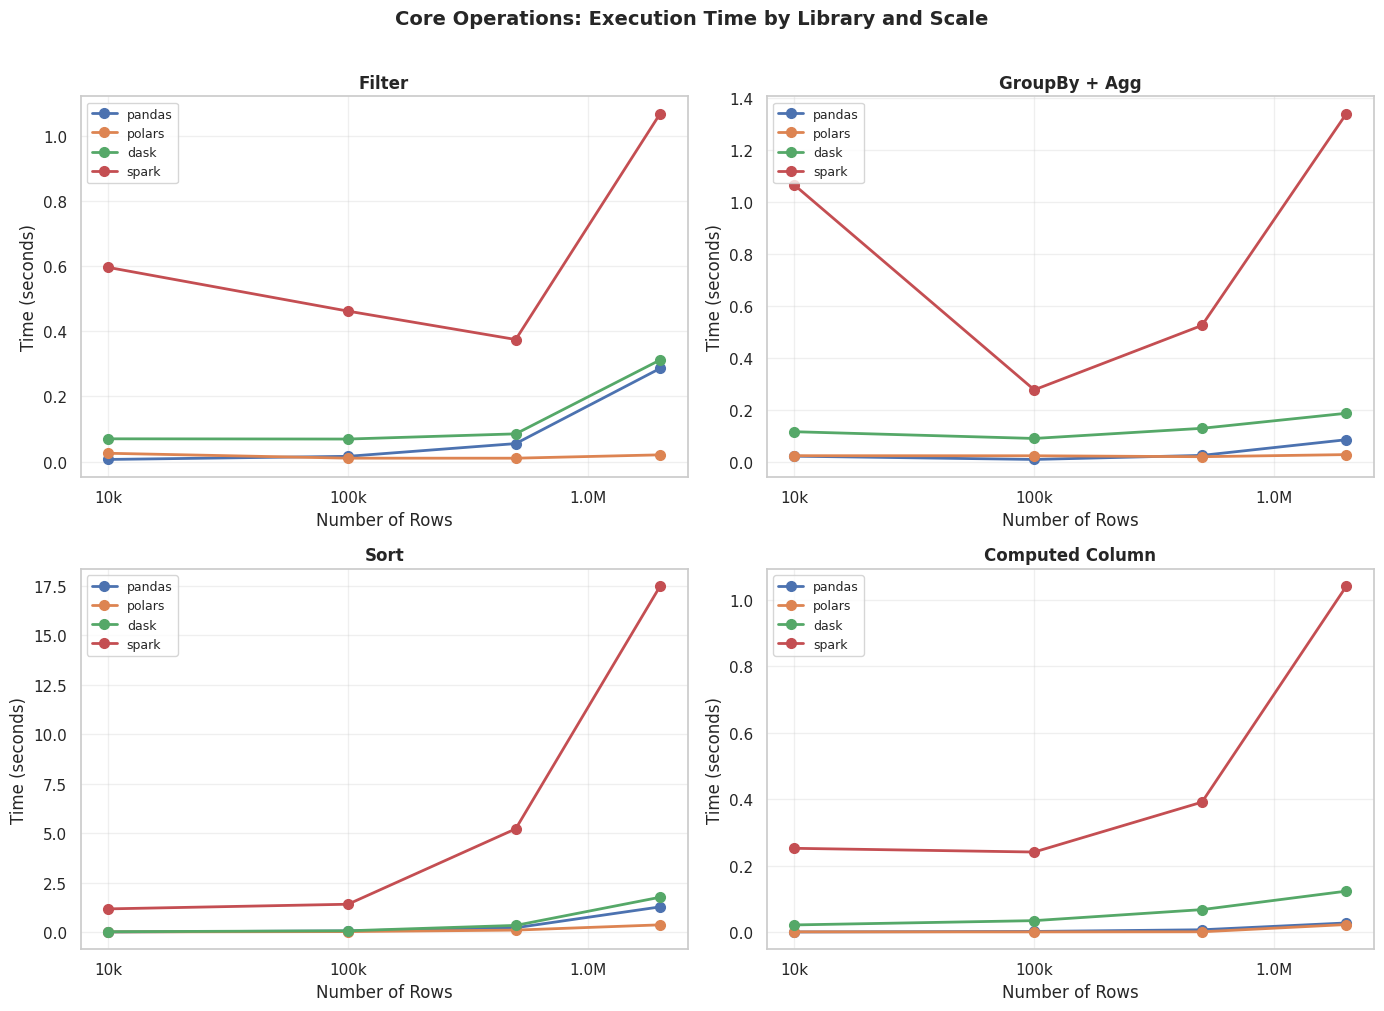

In [10]:
LIB_COLORS = {'pandas': '#4C72B0', 'polars': '#DD8452', 'dask': '#55A868', 'spark': '#C44E52'}
OPERATIONS = ['filter', 'groupby', 'sort', 'computed_col']
OP_LABELS  = {'filter': 'Filter', 'groupby': 'GroupBy + Agg',
              'sort': 'Sort', 'computed_col': 'Computed Column'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, op in enumerate(OPERATIONS):
    ax = axes[idx]
    op_data = df_results[df_results['operation'] == op]

    for lib in LIBRARIES:
        lib_data = op_data[op_data['library'] == lib].sort_values('n_rows')
        ax.plot(lib_data['n_rows'], lib_data['time_s'],
                marker='o', linewidth=2, markersize=7,
                color=LIB_COLORS[lib], label=lib)

    ax.set_title(OP_LABELS[op], fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Rows')
    ax.set_ylabel('Time (seconds)')
    ax.set_xscale('log')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k'))

plt.suptitle('Core Operations: Execution Time by Library and Scale',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.2 – Pipeline Benchmark: End-to-End Comparison

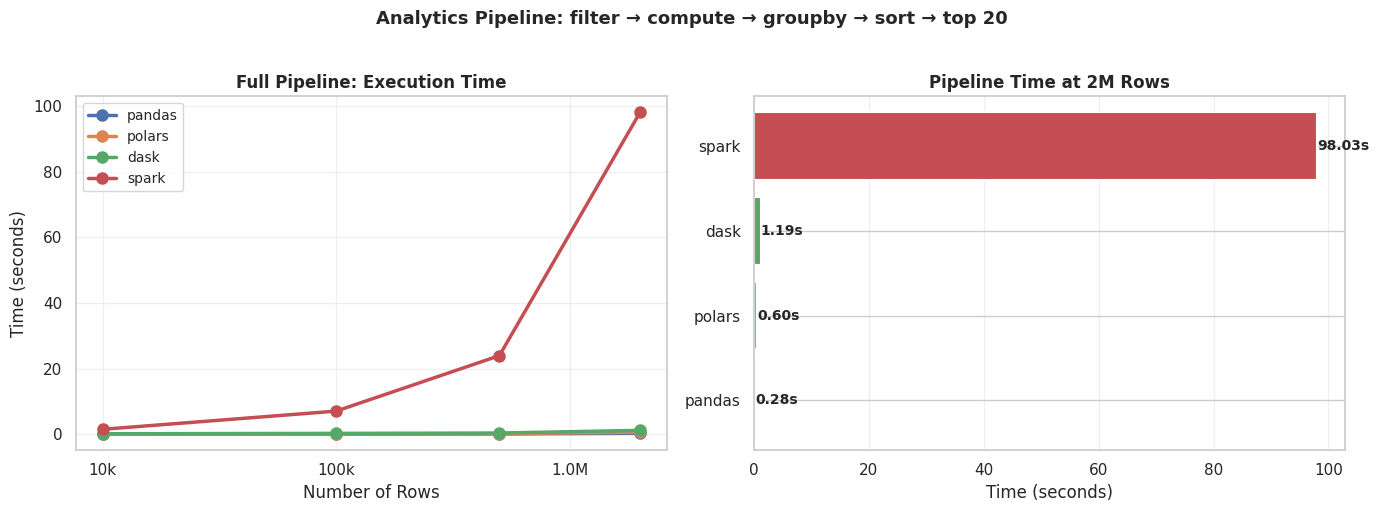

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: line chart — total pipeline time vs. rows
ax = axes[0]
for lib in LIBRARIES:
    lib_data = df_pipeline[df_pipeline['library'] == lib].sort_values('n_rows')
    ax.plot(lib_data['n_rows'], lib_data['time_s'],
            marker='o', linewidth=2.5, markersize=8,
            color=LIB_COLORS[lib], label=lib)

ax.set_title('Full Pipeline: Execution Time', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Rows')
ax.set_ylabel('Time (seconds)')
ax.set_xscale('log')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k'))

# Right: grouped bar chart at largest scale
ax2 = axes[1]
largest_scale = list(SCALE_LEVELS.keys())[-1]
largest_data = df_pipeline[df_pipeline['scale'] == largest_scale].sort_values('time_s')

bars = ax2.barh(largest_data['library'], largest_data['time_s'],
                color=[LIB_COLORS[lib] for lib in largest_data['library']],
                edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, largest_data['time_s']):
    ax2.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}s', va='center', fontweight='bold', fontsize=10)

ax2.set_title(f'Pipeline Time at {largest_scale} Rows', fontsize=12, fontweight='bold')
ax2.set_xlabel('Time (seconds)')
ax2.grid(axis='x', alpha=0.3)

plt.suptitle('Analytics Pipeline: filter → compute → groupby → sort → top 20',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.3 – Speedup Relative to pandas

Speedup vs. pandas (pipeline benchmark):
  (>1 = faster than pandas, <1 = slower than pandas)

library  dask  pandas  polars  spark
scale                               
10k      0.23     1.0    1.43   0.02
100k     0.11     1.0    0.93   0.00
500k     0.23     1.0    0.46   0.00
2M       0.24     1.0    0.47   0.00


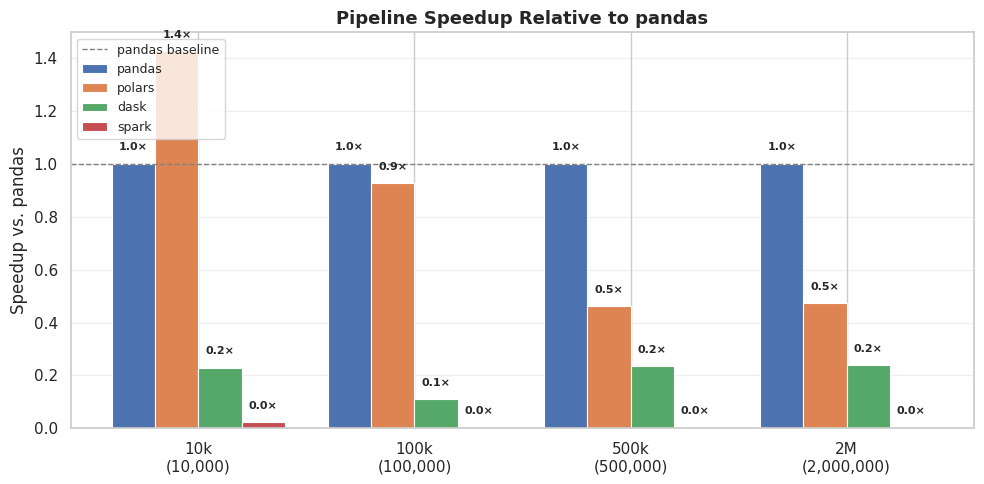

In [12]:
# Compute speedup relative to pandas for the pipeline
pivot = df_pipeline.pivot_table(index='scale', columns='library', values='time_s')
# Reorder by scale
scale_order = list(SCALE_LEVELS.keys())
pivot = pivot.reindex(scale_order)

speedup = pivot.copy()
for col in speedup.columns:
    speedup[col] = pivot['pandas'] / pivot[col]

print('Speedup vs. pandas (pipeline benchmark):')
print('  (>1 = faster than pandas, <1 = slower than pandas)')
print()
print(speedup.round(2).to_string())

# Visualise
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(scale_order))
width = 0.2

for i, lib in enumerate(LIBRARIES):
    vals = [speedup.loc[s, lib] if s in speedup.index else 0 for s in scale_order]
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, vals, width, label=lib, color=LIB_COLORS[lib],
                  edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{v:.1f}×', ha='center', fontsize=8, fontweight='bold')

ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='pandas baseline')
ax.set_xticks(x)
ax.set_xticklabels([f'{s}\n({SCALE_LEVELS[s]:,})' for s in scale_order])
ax.set_ylabel('Speedup vs. pandas')
ax.set_title('Pipeline Speedup Relative to pandas', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4 – Memory Usage Comparison

Memory usage for 100k rows:
  pandas:    18.3 MB
  polars:    15.2 MB  (Arrow columnar format)
  dask:    ~ 18.3 MB  (partitioned pandas)
  spark:   (JVM-managed, not directly comparable)

Polars uses 1.2× less memory than pandas
(Apache Arrow columnar format is more memory-efficient for analytics)


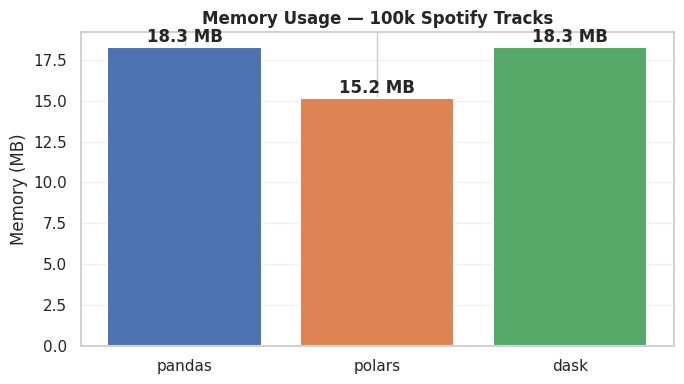

In [13]:
import sys

# Compare memory footprint of the same data in different formats
test_df = datasets_pd['100k']

pd_mem = test_df.memory_usage(deep=True).sum() / 1024**2
pl_mem = pl.from_pandas(test_df).estimated_size('mb')
# Dask is just partitioned pandas, so same memory model
dask_mem = pd_mem  # approximately equal

print(f'Memory usage for 100k rows:')
print(f'  pandas:  {pd_mem:6.1f} MB')
print(f'  polars:  {pl_mem:6.1f} MB  (Arrow columnar format)')
print(f'  dask:    ~{dask_mem:5.1f} MB  (partitioned pandas)')
print(f'  spark:   (JVM-managed, not directly comparable)')
print()
print(f'Polars uses {pd_mem / pl_mem:.1f}× less memory than pandas')
print(f'(Apache Arrow columnar format is more memory-efficient for analytics)')

fig, ax = plt.subplots(figsize=(7, 4))
libs = ['pandas', 'polars', 'dask']
mems = [pd_mem, pl_mem, dask_mem]
colors = [LIB_COLORS[l] for l in libs]
bars = ax.bar(libs, mems, color=colors, edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, mems):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{v:.1f} MB', ha='center', fontweight='bold')
ax.set_ylabel('Memory (MB)')
ax.set_title('Memory Usage — 100k Spotify Tracks', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5 – When to Use Which Library?

| Scenario | Recommended library | Why |
|---|---|---|
| Quick exploration (<100k rows) | **pandas** | Simplest API, huge ecosystem, no setup |
| Fast analytics on a laptop (up to ~50 GB) | **Polars** | Columnar, multi-threaded, lazy optimisation |
| Existing pandas code that needs to scale | **Dask** | Drop-in replacement, familiar API |
| True Big Data on a cluster (TB+) | **Spark** | Distributed across hundreds of machines |
| Real-time streaming data | **Spark** | Spark Streaming is production-proven |
| One-off data cleaning script | **pandas** | Fastest to write, most tutorials available |

> 💡 **Key insight:** There is no single "best" library. The right choice depends on your data size, infrastructure, and team expertise. A common pattern in industry is to **prototype in pandas**, then **switch to Polars or Spark** when the data outgrows a single machine.

---

> ✏️ **Exercise 1:** Look at the benchmark charts. At which data size does Polars start to clearly outperform pandas? Why does Spark perform relatively poorly at small data sizes?

*(Write your answer here)*

---

> ✏️ **Exercise 2:** A startup has 500 GB of user event data stored on a single server with 64 GB RAM. They currently use pandas and it crashes. Which library would you recommend as a first step, and why? Would your answer change if they expected to grow to 10 TB within a year?

*(Write your answer here)*

---
## ✅ Session Summary

By the end of this session you should be able to:

- [ ] 🐼 Explain when **pandas** is the right tool — and when it isn't
- [ ] ⚡ Describe why **Polars** is faster (columnar storage, Rust, multi-threading)
- [ ] 🔄 Explain how **Dask** parallelises pandas by splitting into partitions
- [ ] 🚀 Explain why **Spark** has high startup overhead but scales to clusters
- [ ] 💤 Describe what **lazy evaluation** means and why it helps (Polars + Spark)
- [ ] 📊 Read benchmark charts and draw conclusions about scaling behaviour
- [ ] 🧭 Recommend the right library for a given data size and team context
- [ ] 🔧 Write basic operations (filter, groupby, sort) in all four libraries